![NWM](img/NWM.png)

# Watershed-Scale Analysis of ParFlow-CONUS Snow Outputs
Authors: Irene Garousi-Nejad (igarousi@cuahsi.org), Danielle Tijerina-Kreuzer (dtijerina@cuahsi.org)  
Last updated: February 2026

**Introduction**: This notebook uses the Princeton HydroData repository to gather [gridded ParFlow-CONUS1 SWE outputs](https://hf-hydrodata.readthedocs.io/en/latest/gridded_data/gridded_methods.html#get-gridded-data). See this [page more info on the PF-CONUS1 outputs](https://hf-hydrodata.readthedocs.io/en/latest/available_datasets.html#parflow-simulation-outputs).  
See the `hf_hydrodata` [Getting Started](https://hf-hydrodata.readthedocs.io/en/latest/getting_started.html) page for more information on the package and account.  
 
It uses Snotel data that is collected in the `01_data_collection.ipynb` notebook.  

### 1. Prepare the Python Environment

In [27]:
import os
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import hf_hydrodata as hf
import subsettools

from utils import nwm_utils

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1b. Register Pin and Access HydroData

To access the HydroData catalog you will need to sign up for a [HydroFrame account](https://hydrogen.princeton.edu/signup) (do this only once), [create a 4-digit PIN](https://hydrogen.princeton.edu/pin), and register your pin in order to have access to the HydroData datasets (you will do this in the next code cell below). To note, you PIN will expire after 7 days and will need to recreate it after that time. 

In [2]:
# You need to register on https://hydrogen.princeton.edu/pin 
# and run the following with your registered information
# before you can use the hydrodata utilities
hf.register_api_pin("dtt2@princeton.edu", "7837")

### 1c. Dask  

We'll use dask to parallelize our code. To manage parallel computation and visualize progress of long-running tasks, we initialize a Dask “cluster,” which defines how many workers are used and how much computing power each worker has. 

In this setup, we create a Dask client with `Client(n_workers=6, threads_per_worker=1, memory_limit='2GB')`, which launches a cluster with 6 workers. Each worker uses a single thread, typically mapped to one CPU core, allowing for efficient parallel processing across 6 cores. Each worker also has a memory limit of 2 GB, for a total of up to 12 GB across the cluster.

In [3]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print('Dashboard link:', client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    client = Client(n_workers=6, threads_per_worker=1, memory_limit='2GB') 
    print('Dashboard link:', client.dashboard_link)
print(client)

/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53156 instead
  warnings.warn(


Dashboard link: http://127.0.0.1:53156/status
<Client: 'tcp://127.0.0.1:53157' processes=6 threads=6, memory=11.18 GiB>


## 2. Subset the modeled dataset to the watershed of interest

In this notebook, we take a deeper dive into analyzing the PF-CONUS1 snow model gridded outputs across the entire East-Taylor watershed. To do so, we'll use the same method from the point scale analysis (Notebook 02), using the HUC-08 ID to retrieve the SWE outputs for the East-Taylor over the period of interest. 

In [ ]:
# Start and end times of a water year (note that this code currently works for one water year)
StartDate = '2003-10-01'
EndDate = '2005-09-30'

# Path to the watershed shapefile
watershed = './domain_data/East-Taylor_14020001.shp'
conus_latlon_gdf = gpd.read_file('./domain_data/East-Taylor_conus1_gridPoints_LatLon.shp')

# Read in SNOTEL observations from 01_HydroData_collection.ipynb 
obs_df = pd.read_csv(os.path.join('obs_outputs_PF', 'df_East-Taylor_14020001_SNOTEL.csv'))
obs_df = obs_df.set_index("date")
obs_df.index = pd.to_datetime(obs_df.index)

# Observations metadata 
metadata_df = pd.read_csv(os.path.join('obs_outputs_PF', 'df_East-Taylor_14020001_SNOTEL_metadata.csv'))

### 2a. Define the watershed of interest

We will continue to work with the same East-Taylor watershed from snow notebooks 01 & 02. The East-Taylor HUC-08 id is entered in the next cell.  

_Reminder:_ One of the simplest ways to gather data and model output from HydroData is by specifying a [Hydrologic Unit Code](https://www.usgs.gov/national-hydrography/watershed-boundary-dataset). Before we retrieve any hydrologic information, we need to indicate a HUC8 code and use it to gather snow water equivalent (SWE) observations from SNOTEL sites  

✏️ If you have a specific HUC8 in mind, you can change the variable `huc_8_code` below.

In [5]:
# ✏️ Specify HUC8 ID and Name for watershed of interest
huc_8_code = '14020001'  # East-Taylor HUC-8
print(f'HUC-8 ID: {huc_8_code}')

huc_8_name = 'East-Taylor'
print(f'HUC-8 name: {huc_8_name}')

HUC-8 ID: 14020001
HUC-8 name: East-Taylor


Set up the daily and monthly time indices  
both for plotting and for monthly aggregation

In [6]:
# Set up a time index for the water year, since the np array returned doesn't have a time variable
day_times = pd.date_range(start=StartDate, end=EndDate, freq="D")
print(f"Number of days in the water year: {len(day_times)}")

month_times = pd.date_range("2003-10-01", periods=12, freq="MS")
print(f"Month start times: {month_times}")

day_times

Number of days in the water year: 731
Month start times: DatetimeIndex(['2003-10-01', '2003-11-01', '2003-12-01', '2004-01-01',
               '2004-02-01', '2004-03-01', '2004-04-01', '2004-05-01',
               '2004-06-01', '2004-07-01', '2004-08-01', '2004-09-01'],
              dtype='datetime64[ns]', freq='MS')


DatetimeIndex(['2003-10-01', '2003-10-02', '2003-10-03', '2003-10-04',
               '2003-10-05', '2003-10-06', '2003-10-07', '2003-10-08',
               '2003-10-09', '2003-10-10',
               ...
               '2005-09-21', '2005-09-22', '2005-09-23', '2005-09-24',
               '2005-09-25', '2005-09-26', '2005-09-27', '2005-09-28',
               '2005-09-29', '2005-09-30'],
              dtype='datetime64[ns]', length=731, freq='D')

## 3. Retrieve ParFlow-CONUS2 gridded SWE output from HydroData  
Retrieve data from the HydroData using the HUC-08 ID for the East-Taylor watershed. First we create a multidimensional numpy array, which stores daily gridded SWE (with dimensions of `[#days, domain ny, domain nx]`). Then we use the day_times to create a DataArray of daily gridded PF-CONUS1 SWE.  

In [7]:
# retrieve gridded PF-CONUS1 SWE for the entire HUC8 watershed
grid_swe_options = {
        "dataset": "conus1_baseline_mod",
        "variable": "swe",
        "temporal_resolution": "daily",
        "start_time": StartDate, 
        "end_time": '2005-10-01', ### TO NOTE: the gridded function has exclusive end date, so this is hardcoded for now
        "huc_id": huc_8_code
    }
    
    # Get gridded data
grid_swe = hf.get_gridded_data(grid_swe_options)


# View the dimensions of the gridded data, which should be (days, ny, nx)
grid_swe.shape

(731, 49, 68)

### Make a DataArray of the gridded SWE

In [ ]:
ny, nx = grid_swe.shape[1], grid_swe.shape[2]

y_index = np.arange(ny)
x_index = np.arange(nx)

grid_swe_da = xr.DataArray(grid_swe, dims=("time", "ny", "nx"), 
                           coords={"time": day_times, "ny": y_index, "nx": x_index}, name="Modeled SWE")


In [32]:
grid_swe_da

<xarray.DataArray 'Modeled SWE' (time: 731, j: 49, i: 68)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 2003-10-01 2003-10-02 ... 2005-09-30
  * j        (j) int64 0 1 2 3 4 5 6 7 8 9 10 ... 39 40 41 42 43 44 45 46 47 48
  * i        (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64 65 66 67

### DTK TO DO: Make this a slider for all dates

In [14]:
grid_swe_map = grid_swe_da.sel(time="2004-04-01")
grid_swe_map.hvplot.image(cmap="YlGnBu", colorbar=True, aspect="equal", title=f"{huc_8_name} Gridded SWE on 2004-04-01")


:Image   [x,y]   (Modeled SWE)

### Calculate Means
#### a. Daily Means

From the gridded swe `grid_swe` 3D numpy array, compute the daily mean and save as a Pandas dataframe:

In [8]:
mod_daily_mean = np.nanmean(grid_swe, axis=(1, 2))  
mod_daily_mean_df = pd.DataFrame(mod_daily_mean, index=day_times, columns=["mod_basin_mean"])
mod_daily_mean_df.index = pd.to_datetime(mod_daily_mean_df.index)

From the `obs_df` dataframe of the observed SWE at SNOTEL stations, create a new Pandas dataframe of the daily station mean:

In [9]:
# compute the daily mean across all observation sites for each day
obs_daily_mean_df = (obs_df.mean(axis=1).to_frame(name="obs_basin_mean"))

In [11]:
# Combine the daily mean observed and modeled data into a single dataframe for comparison (and plotting)
combined_daily_df = mod_daily_mean_df.join(obs_daily_mean_df, how="inner")
print(combined_daily_df.head())
type(combined_daily_df)

            mod_basin_mean  obs_basin_mean
2003-10-01        0.000000             0.0
2003-10-02        0.000000             0.0
2003-10-03        0.000000             0.0
2003-10-04        0.008404             0.0
2003-10-05        0.000000             0.0


pandas.core.frame.DataFrame

In [ ]:
nwm_utils.comparison_plots(combined_daily_df, 'obs_basin_mean', 'mod_basin_mean')

#### b. Monthly Means

In [12]:
combined_monthly_df = combined_daily_df.resample("MS").mean()
combined_monthly_df.columns = ["mod_monthly_mean", "obs_monthly_mean"]
combined_monthly_df


,mod_monthly_mean,obs_monthly_mean
2003-10-01,0.059553,0.000000
2003-11-01,36.086870,43.095333
2003-12-01,78.614065,95.905484
2004-01-01,147.503349,182.101613
2004-02-01,189.490299,228.249655
2004-03-01,197.776458,252.811935
2004-04-01,166.556244,231.309333
2004-05-01,92.969544,30.111290
2004-06-01,18.603418,0.000000
2004-07-01,0.752959,0.000000


Use the gridded modeled SWE DataArray `grid_swe_da` from earlier in the notebook to compute daily means with the `.resample()` method to group the model output by a monthly frequency and compute the monthly mean. 

In [18]:
grid_monthly_mean = grid_swe_da.resample(time="MS").mean(dim="time", skipna=True)


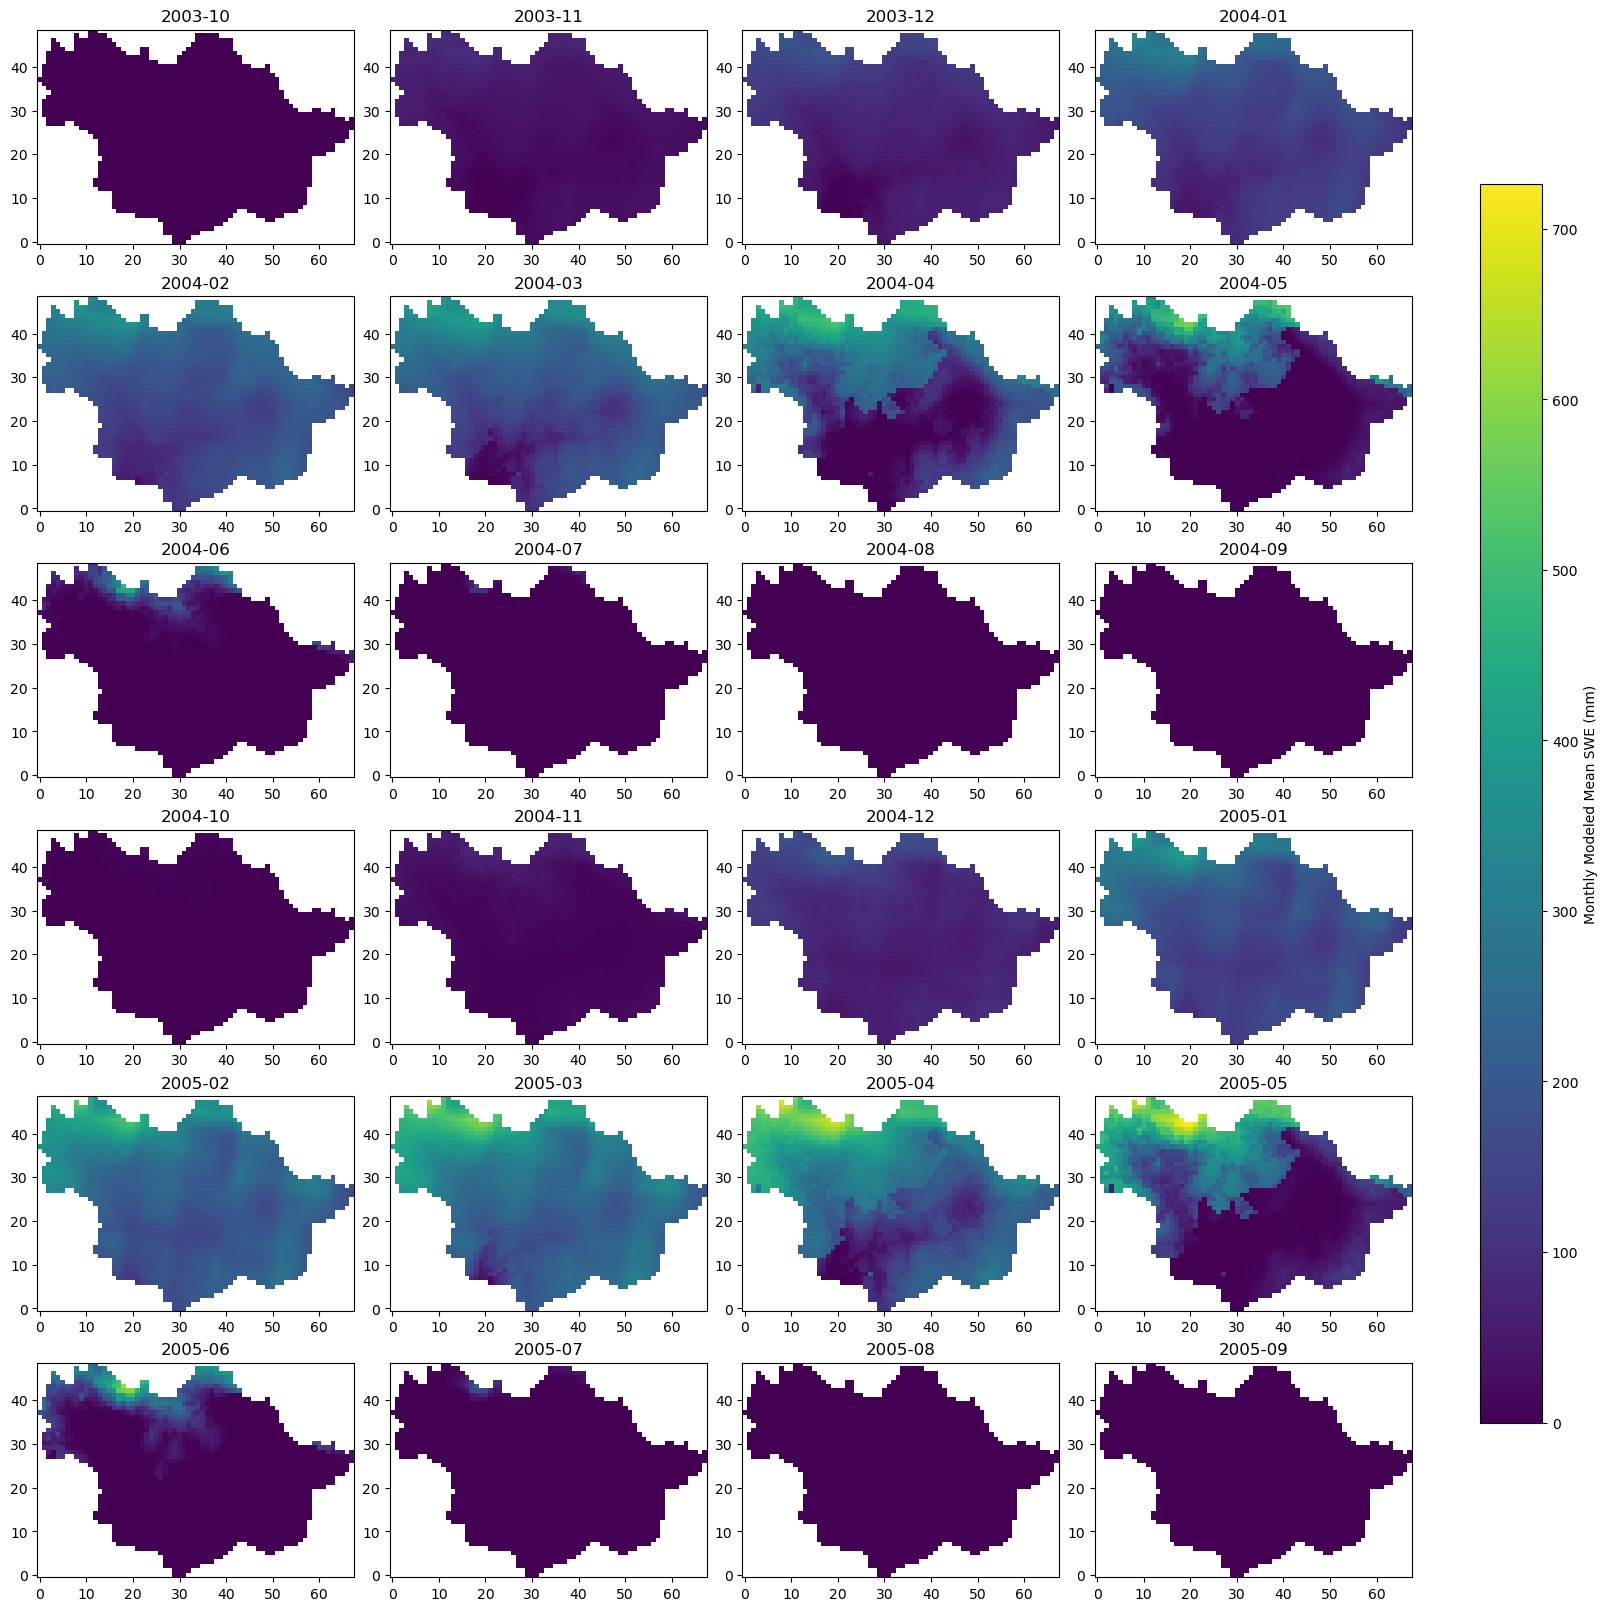

In [25]:
fig, axes = plt.subplots(6, 4, figsize=(16, 16), constrained_layout=True)

vmin = grid_monthly_mean.min().item()
vmax = grid_monthly_mean.max().item()

for i, ax in enumerate(axes.flat):
    grid_monthly_mean.isel(time=i).plot.imshow(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(str(grid_monthly_mean.time.values[i])[:7])
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.colorbar(axes.flat[0].images[0], ax=axes, shrink=0.8, label="Monthly Modeled Mean SWE (mm)")


### Peak SWE

TypeError: The DType <class 'numpy.dtype[datetime64]'> could not be promoted by <class 'numpy.dtype[int64]'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtype[datetime64]'>, <class 'numpy.dtype[int64]'>)

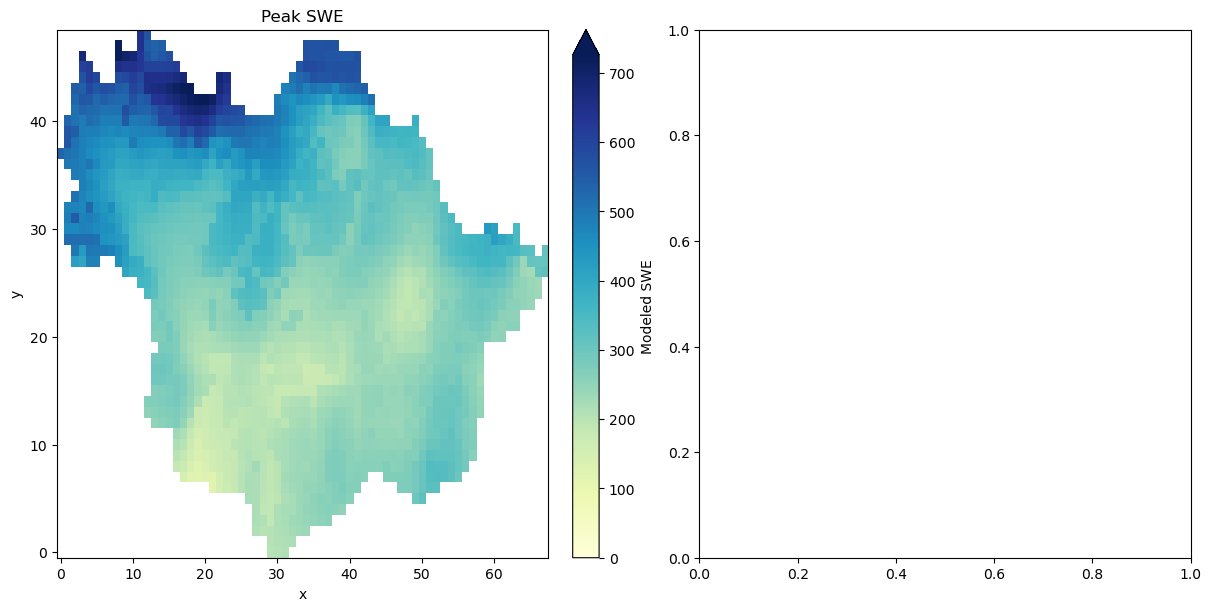

In [28]:
peak_swe = grid_swe_da.max(dim="time")
peak_day = grid_swe_da.idxmax(dim="time")
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
peak_swe.plot.imshow(ax=axes[0], cmap="YlGnBu", vmin=vmin, vmax=vmax)
axes[0].set_title("Peak SWE")
peak_day.plot.imshow(ax=axes[1], cmap="viridis")
axes[1].set_title("Day of Peak SWE")

In [29]:
peak_day

<xarray.DataArray 'time' (y: 49, x: 68)>
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      dtype='datetime64[ns]')
Coordinates:
  * y        (y) int64 0 1 2 3 4 5 6 7 8 9 10 ... 39 40 41 42 43 44 45 46 47 48
  * x        (x) int64 0 1 2 3 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64 65 66 67

Do some GIS stuff

In [ ]:

# Extract the bounding box coordinates of a watershed
watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).to_crs(epsg=4326)

# Create a single geometry for the watershed by dissolving all HUC8-level basins within it.
watershed_huc8 = watershed_gdf.dissolve(by='HUC_8')

# Create geodataframe of all stations
all_stations_gdf = gpd.read_file(snotel_geojson).set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]
filtered_all_stations_gdf = all_stations_gdf[all_stations_gdf.state.str.contains('California')]  

# Extract the bounding box coordinates of a watershed
watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).to_crs(epsg=4326)

# Combine all polygons into a single MultiPolygon
watershed_union = watershed_gdf.geometry.unary_union

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = filtered_all_stations_gdf[filtered_all_stations_gdf.geometry.within(watershed_union)]
gdf_in_bbox.reset_index(inplace=True)
print(f'There are {len(gdf_in_bbox)} sites from', ', '.join(set(gdf_in_bbox.network)), 'network(s) within the watershed.')


We first ensure that the NWM data is loaded and that the domain of interest uses the same coordinate reference system (CRS) as the NWM dataset. This is required when clipping the dataset using rioxarray’s clip method later 

In [ ]:
%time 
ds = xr.open_zarr(store=conus_bucket_url, 
                        consolidated=True, 
                        storage_options={
                        "anon": True,
                        "client_kwargs": {"region_name": "us-east-1"}
                    })
ds.rio.set_crs(ds.crs.attrs['esri_pe_string'])
ds.rio.write_crs(inplace=True);
watershed_huc8_prj = watershed_huc8.to_crs(ds.rio.crs)

Let's clip the gridded data to the extent of this watershed. This can be done using `rioxarray`'s "clip" method.

In [ ]:
%%time
ds_clip = ds.rio.clip(
         watershed_huc8_prj.geometry.values,
         watershed_huc8_prj.crs,
         all_touched=True,   # select all grid cells that touch the vector boundary
         drop=True,          # drop anything that is outside the clipped region
         invert=False,
         from_disk=True).sel(time=slice(StartDate, EndDate))

Preview the data at a specific point in time by defining an **exact date and time** (e.g., '2019-02-01T00:00') or an **index** (e.g., 1000, referring to the 1000th time step in the data array). We will use `hvplot` and `Holoviews` Python packages to create a more informative plot that displays both the gridded data and the vector data. One important note: for `hvplot` to visualize gridded data correctly on a map, all data must be in a **geographic coordinate system** (e.g., EPSG:4326). Note that it may take a while for the following task (map visualization) to be completed.

In [ ]:
# Explore the time values
ds_clip.time.values

In [ ]:
# Explore the variable of interest. We will be working with SNEQV, which is SWE. But feel free to explore other varibales. Note that for some of these varibales, the dimension is different and the funciton may not work for all.
ds_clip.data_vars

In [ ]:
# Define the time and variable of interest
data_var='SNEQV'
time_index='2019-01-01T00:00:00.000000000'

nwm_utils.plot_grid_vector_data(ds_clip, data_var, time_index, watershed_huc8, gdf_in_bbox)

Go ahead and play around with the time slider above to see how SWE changes over time across the watershed. 

<div style="background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🔍 Explore</h4>
  <p>
    Using the zoom options in the hvplot toolbar, can you comment on the possible reasons for the missing values or pixels visible on the map?
  </p>
</div>

### 3. Compare the spatial average SWE across the entire watershed

This analysis requires us to compute the spatial average for both observed and modeled snow water equivilent data and create a single Pandas DataFrame that combines the basin-averaged modeled data with the observed data for direct comparison. To do this, we'll read the observed data collected in the `01_data_collection.ipynb` notebook. 

In [ ]:
df_obs_swe_mean

In [ ]:
# Observed data
df_obs_swe_mean = nwm_utils.compute_spatial_agg_from_obs('./obs_outputs', 'mean')
df_obs_swe_mean['Date'] = pd.to_datetime(df_obs_swe_mean['Date']).dt.date


In [ ]:
# Modeled data
ds_clip_swe_mean = ds_clip.SNEQV.mean(dim=(['x', 'y'])).sel(time=slice(StartDate, EndDate)).compute()
df_mod_swe_mean = nwm_utils.prep_nwm_swe_dataframe(ds_clip_swe_mean, gdf_in_bbox.iloc[0].state)
df_mod_swe_mean['Date_Local'] = pd.to_datetime(df_mod_swe_mean['Date_Local']).dt.date

In [ ]:
# Combine
combined_df_mean = pd.merge(
    df_mod_swe_mean, df_obs_swe_mean, 
    left_on='Date_Local',  
    right_on='Date',       
    how='inner'  
)
combined_df_mean = combined_df_mean[['Date_Local', 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters']]
combined_df_mean.index = pd.to_datetime(combined_df_mean['Date_Local'])


Create plots and compute stats

In [ ]:
# Plot
nwm_utils.comparison_plots(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

In [ ]:
# Stats
nwm_utils.compute_stats(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

<div style="background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    What could be the potential sources of discrepancies between the spatially averaged SWE from the modeled and observed datasets within this catchment?  
How could you generate more reliable or informative statistics?  
How do you think the presence of SWE values equal to zero across large areas of the gridded dataset (as seen in the map above) — particularly when this pattern is consistent across the water year — might impact the spatially averaged SWE values?  
How could this influence your interpretation?
  </p>
</div>

### 4. Compare the spatial average SWE across a catchment within the watershed

#### Don Pedro Reservoir Basin

Repeat the steps above, but this time focus on a smaller domain. For example, the upstream catchments of the Don Pedro Reservoir (DonPedroDam_Upstream_Basin.shp). This allows us to examine the impact of excluding areas where SWE is zero for the majority of days within a water year. Could this approach improve the statistical comparison between modeled and observed SWE?

In [ ]:
donpedro_gdf = gpd.read_file(os.path.join(os.getcwd(), basin)).to_crs(epsg=4326)
donpedro_gdf_prj = donpedro_gdf.to_crs(ds.rio.crs)
ds_clip_donpedro = ds.rio.clip(
         donpedro_gdf_prj.geometry.values,
         donpedro_gdf_prj.crs,
         all_touched=True,   
         drop=True,         
         invert=False,
         from_disk=True).sel(time=slice(StartDate, EndDate))

In [ ]:
# Define the time and variable of interest
data_var='SNEQV'
time_index='2019-01-01T00:00:00.000000000'

nwm_utils.plot_grid_vector_data(ds_clip_donpedro, data_var, time_index, donpedro_gdf, gdf_in_bbox)

In [ ]:
# Modeled data
ds_clip_swe_mean = ds_clip_donpedro.SNEQV.mean(dim=(['x', 'y'])).sel(time=slice(StartDate, EndDate)).compute()
df_mod_swe_mean = nwm_utils.prep_nwm_swe_dataframe(ds_clip_swe_mean, gdf_in_bbox.iloc[0].state)

# Observed data
df_obs_swe_mean = nwm_utils.compute_spatial_agg_from_obs('./obs_outputs', 'mean')
df_obs_swe_mean['Date'] = pd.to_datetime(df_obs_swe_mean['Date']).dt.date
df_mod_swe_mean['Date_Local'] = pd.to_datetime(df_mod_swe_mean['Date_Local']).dt.date

# Combine with the observed data
combined_df_mean = pd.merge(
    df_mod_swe_mean, df_obs_swe_mean, 
    left_on='Date_Local',  
    right_on='Date',       
    how='inner'  
)
combined_df_mean = combined_df_mean[['Date_Local', 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters']]
combined_df_mean.index = pd.to_datetime(combined_df_mean['Date_Local'])

# Plot
nwm_utils.comparison_plots(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

In [ ]:
# Stats
nwm_utils.compute_stats(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

Visualize both the temporal and spatial variability of modeled SWE across the domain. To achieve this, we first create a subset of the modeled data by selecting only the first time step of each month from the simulated SWE dataset. To improve processing efficiency, we chunk the dataset along the time dimension, allowing faster access to individual time slices. We then apply a time filter and compute each selected slice individually to avoid excessive memory use. Finally, we combine the computed slices back into a single dataset for analysis and visualization.

In [ ]:
# Check the current chunks
ds_clip_donpedro.chunks

In [ ]:
# Rechunck
ds_clip_donpedro = ds_clip_donpedro.chunk({'time': 1})

**Note**: The following code may take several minutes to run.

In [ ]:
%%time 

# Apply time filter
mask = (ds_clip_donpedro.time.dt.is_month_start) & (ds_clip_donpedro.time.dt.hour == 0)

# Compute in smaller pieces
selected_times = ds_clip_donpedro.time[mask]
parts = []
for t in selected_times.values:
    part = ds_clip_donpedro.sel(time=t).compute()  # One slice at a time
    parts.append(part)

# Combine the pieces
ds_monthly_start = xr.concat(parts, dim='time')

In [ ]:
data_var='SNEQV'
nwm_utils.plot_grid_vector_monthly_data(ds_monthly_start, data_var, donpedro_gdf, gdf_in_bbox)

<div style="background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    In the plot above, you can see that in both accumulation and melt periods (e.g., Feb-Jun), snow was present in areas not covered by the existing observation points.  
How would having more observation points distributed across these snow-covered areas affect the basin-average SWE from observations, as calculated and plotted previously (`combined_df_mean`)?  
How could this change influence the bias, Nash-Sutcliffe Efficiency (NSE), and other statistical comparisons between modeled and observed SWE?  
And, how might improving the capture of spatial variability in SWE affect forecasts under future climate conditions?
  </p>
</div>